In [1]:
%config InlineBackend.figure_format='retina'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


/var/folders/2m/t5bb62r50jbb_r1gf5dsdy680000gr/T/ipykernel_96320/1445354026.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Cleaning up Data Suitable for DMD Analysis

Importing marker data from bird flight wings and tail for DMD analysis. 

### Initial Wingbeat Data

First saving the initial wingbeat for each bird and each experimental condition.

In [67]:

# Define filtering function
def filter_data(data, 
                starts_with_string=None, 
                contains_string=None, 
                condition_dict=None):
    if starts_with_string is not None:
        data = data[data['frameID'].str.startswith(starts_with_string)]
    
    if contains_string is not None:
        data = data[data['frameID'].str.contains(contains_string)]
    
    if condition_dict is not None:
        for key, value in condition_dict.items():
            data = data[data[key] == value]
    
    return data.reset_index(drop=True)

def save_npz(markers, info, string_info):

    if markers.shape[0] > 0:
        
        print(string_info, markers.shape)
        # Save as numpy zip array
        np.savez_compressed("../../data/processed/"+string_info+".npz", markers=markers, info=info)
                        
                    



Loading the full dataset

In [3]:
full_data = pd.read_csv("../../data/raw/full_allBirds_unilateral_markers.csv")

# Create new sequence column
full_data['Seq'] = [int(ii.split('_')[2]) for ii in full_data['frameID']]

# Make sure ordered by frameID
full_data = full_data.sort_values(by=['frameID']).reset_index(drop=True)


## Subsetting Data

This dataset contains 5 birds and 4 flight distances. For the 9m flights, there are also with and without weight, and with and without an obstacle. The following separates the data into the different conditions and saves them as npz files. 

- In 2017: Drogon, Rhaegal and Toothless were juveniles; Ruby was an adult. They flew 5m, 7m, 9m, 12m without weights or obstacles. 
- In 2020: Charmander was a juvenile; Drogon, Ruby and Toothless were adults. They flew 9m with and without weights and obstacles.

To distinguish 2017 and 2020 9m flights without weight or obstacles, the 2020 flights are labeled as `9m_2020`. This means `Drogon_9m` and `Drogon_9m_2020` show his juvenile and adult flights respectively (and same for Toothless). 

The 2020 data is not calibrated in time with the jump. 

In [68]:

bird_dict = {"drogon":"01_",
            "rhaegal":"02_",
            "ruby":"03_",
             "toothless":"04_",
             "charmander":"05_"}

perchDist_dict = {"5m":"05_",
                  "7m":"07_",
                  "9m":"09_",
                  "12m":"12_"}

obstacle_dict = {"":0,
                 "_obst":1}
imu_dict = {"":0,
            "_weight":1}

left_dict = {"right":0,
            "left":1}

info_columns = ['time', 'frame','frameID', 'HorzDistance', 'Seq']
oldmarker_columns = ['wingtip_rot_xyz_1',	'wingtip_rot_xyz_2',    'wingtip_rot_xyz_3',
                  'primary_rot_xyz_1',  'primary_rot_xyz_2',	'primary_rot_xyz_3',	
                  'secondary_rot_xyz_1','secondary_rot_xyz_2',	'secondary_rot_xyz_3',	
                  'tailtip_rot_xyz_1',	'tailtip_rot_xyz_2',	'tailtip_rot_xyz_3']

rename_dict_left = {
                'wingtip_rot_xyz_1':'left_wingtip_x',     'wingtip_rot_xyz_2':'left_wingtip_y',     'wingtip_rot_xyz_3':'left_wingtip_z',
                'primary_rot_xyz_1':'left_primary_x',     'primary_rot_xyz_2':'left_primary_y',     'primary_rot_xyz_3':'left_primary_z',
                'secondary_rot_xyz_1':'left_secondary_x', 'secondary_rot_xyz_2':'left_secondary_y', 'secondary_rot_xyz_3':'left_secondary_z',
                'tailtip_rot_xyz_1':'left_tailtip_x',     'tailtip_rot_xyz_2':'left_tailtip_y',     'tailtip_rot_xyz_3':'left_tailtip_z'}

rename_dict_right = {
                'wingtip_rot_xyz_1':'right_wingtip_x',     'wingtip_rot_xyz_2':'right_wingtip_y',     'wingtip_rot_xyz_3':'right_wingtip_z',
                'primary_rot_xyz_1':'right_primary_x',     'primary_rot_xyz_2':'right_primary_y',     'primary_rot_xyz_3':'right_primary_z',
                'secondary_rot_xyz_1':'right_secondary_x', 'secondary_rot_xyz_2':'right_secondary_y', 'secondary_rot_xyz_3':'right_secondary_z',
                'tailtip_rot_xyz_1':'right_tailtip_x',     'tailtip_rot_xyz_2':'right_tailtip_y',     'tailtip_rot_xyz_3':'right_tailtip_z'}


for bird in bird_dict:
    for perchDist in perchDist_dict:
        for obstacle in obstacle_dict:
            for IMU in imu_dict:
            
                starts_with_string = bird_dict[bird] + perchDist_dict[perchDist]

                subset_left = filter_data(full_data, 
                                    starts_with_string=starts_with_string,
                                    condition_dict={"Obstacle" : obstacle_dict[obstacle],
                                                    "IMU" : imu_dict[IMU],
                                                    "Left" : 0})
                subset_right = filter_data(full_data,
                                    starts_with_string=starts_with_string,
                                    condition_dict={"Obstacle" : obstacle_dict[obstacle],
                                                    "IMU" : imu_dict[IMU],
                                                    "Left" : 1})

                
                # Rename the columns
                column_names = info_columns + oldmarker_columns
                subset_left = subset_left[column_names].rename(columns=rename_dict_left)
                subset_right = subset_right[column_names].rename(columns=rename_dict_right)

                

                # Merge the two dataframes using the frameID. If the frameID is not in both dataframes, everything will be included in the final dataframe, but with NaN values for the missing columns. This is called a 
                subset = pd.merge(subset_left, subset_right, on=info_columns, how='outer')
                
                
                # If the flight distance is 9m, for drogon and toothless the data can also be split 
                # into 2017 flights (juvenile) and 2020 flights (adult). 
                # 2020 flights have 4 underscores in the frameID, while 2017 flights have 3 underscores.
                
                # Adult Ruby:           all flights
                # Juvenile Rhaegal:     all flights
                # Juvenile Charmander:  all flights
                # Juvenile Toothless:   5m, 7m, 12m flights, and 9m flights from 2017
                # Juvenile Drogon:      5m, 7m, 12m flights, and 9m flights from 2017
                # Adult Drogon:         9m flights from 2020
                # Adult Toothless:      9m flights from 2020

                if perchDist == "9m" and obstacle == "" and IMU == "":
                    flights2020 = subset[subset['frameID'].str.count('_') == 4]
                    subset = subset[subset['frameID'].str.count('_') == 3] # This is saved in the usual way below

                    string_info = bird+"_"+perchDist+obstacle+IMU+"_2020"

                    # Change to numpy array
                    # Remove the columns using info_columns. we can use the drop method to remove the columns
                    markers = flights2020.drop(columns=info_columns).to_numpy()
                    info = flights2020[info_columns].to_numpy()
                    save_npz(markers, info, string_info)

            

                # Change to numpy array
                # Remove the columns using info_columns. we can use the drop method to remove the columns
                markers = subset.drop(columns=info_columns).to_numpy()
                info = subset[info_columns].to_numpy()

                string_info = bird+"_"+perchDist+obstacle+IMU
                save_npz(markers, info, string_info)
                


marker_columns = subset.drop(columns=info_columns).columns.to_numpy()
                    
# Also save the column names for reference
np.save("../../data/processed/marker_column_names.npy", marker_columns)
np.save("../../data/processed/info_column_names.npy", info_columns)
                


drogon_5m (14239, 24)
drogon_7m (9140, 24)
drogon_9m_2020 (9099, 24)
drogon_9m (15730, 24)
drogon_9m_weight (2812, 24)
drogon_9m_obst (4889, 24)
drogon_9m_obst_weight (3863, 24)
drogon_12m (5050, 24)
rhaegal_5m (9074, 24)
rhaegal_7m (11087, 24)
rhaegal_9m (24088, 24)
rhaegal_12m (12493, 24)
ruby_5m (4769, 24)
ruby_7m (11477, 24)
ruby_9m_2020 (12411, 24)
ruby_9m (7266, 24)
ruby_9m_weight (4936, 24)
ruby_9m_obst (6298, 24)
ruby_9m_obst_weight (6293, 24)
ruby_12m (4266, 24)
toothless_5m (6148, 24)
toothless_7m (6722, 24)
toothless_9m_2020 (12763, 24)
toothless_9m (12535, 24)
toothless_9m_weight (3991, 24)
toothless_9m_obst (7276, 24)
toothless_9m_obst_weight (6574, 24)
toothless_12m (42676, 24)
charmander_9m_2020 (9986, 24)
charmander_9m_weight (3477, 24)
charmander_9m_obst (5718, 24)
charmander_9m_obst_weight (4639, 24)


In [344]:
bird = "ruby"
perchDist = "12m"
obstacle = ""
IMU = ""

file_name = bird + "_" + perchDist + obstacle + IMU

# Load a file to check
data = np.load("../../data/processed/"+ file_name + ".npz", allow_pickle=True)
markers = data['markers']
info = data['info']
marker_columns = np.load("../../data/processed/marker_column_names.npy",allow_pickle=True)
info_columns = np.load("../../data/processed/info_column_names.npy",allow_pickle=True)

print(markers.shape)
print(info.shape)

# Create pandas dataframe
data = pd.DataFrame(info, columns=info_columns)
data = pd.concat([data, pd.DataFrame(markers, columns=marker_columns)], axis=1)
data.sort_values(by=['frameID']).reset_index(drop=True)


(7266, 24)
(7266, 4)


,time,frameID,HorzDistance,Seq,left_wingtip_x,left_wingtip_y,left_wingtip_z,left_primary_x,left_primary_y,left_primary_z,...,right_wingtip_z,right_primary_x,right_primary_y,right_primary_z,right_secondary_x,right_secondary_y,right_secondary_z,right_tailtip_x,right_tailtip_y,right_tailtip_z
0,0.0,03_09_043_003262,8.309433,43,0.360926,-0.072886,-0.353212,0.240834,-0.020155,-0.258442,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,03_09_043_003262,8.309433,43,0.218234,-0.192412,-0.113452,0.240834,-0.020155,-0.258442,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.005,03_09_043_003263,8.287111,43,0.322849,-0.077317,-0.364835,0.220063,-0.012352,-0.255587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.01,03_09_043_003264,8.265032,43,0.286499,-0.080338,-0.368942,0.206972,-0.003214,-0.245878,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.015,03_09_043_003265,8.243194,43,0.255382,-0.077442,-0.365772,0.202624,0.004640,-0.231045,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7261,1.625,03_09_376_002647,0.33365,376,0.473519,0.103835,-0.220863,0.305118,0.150566,-0.201989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7262,1.63,03_09_376_002648,0.324699,376,0.467728,0.107068,-0.229707,0.298726,0.151619,-0.207582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7263,1.635,03_09_376_002649,0.316603,376,0.460832,0.110404,-0.238977,0.291899,0.152066,-0.213663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7264,1.64,03_09_376_002650,0.309379,376,0.454535,0.114652,-0.249402,0.285057,0.151926,-0.220114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Splitting into Flight Modes

Now we have separated the data based on experimental condition and bird identity, we can split the data into the different flight modes. These are defined by distance to the perch. 

For 9m flights, flapping is from 0 secs to 0.78


In [346]:

# Time
initial_lims = {"drogon":     {"5m": 0.21, "7m": 0.20, "9m": 0.21, "12m": 0.22},
                "rhaegal":    {"5m": 0.21, "7m": 0.17, "9m": 0.22, "12m": 0.21},
                "ruby":       {"5m": 0.23, "7m": 0.22, "9m": 0.25, "12m": 0.26},
                "toothless":  {"5m": 0.21, "7m": 0.22, "9m": 0.22, "12m": 0.20},
                "charmander": {"9m": 0.3}}

# Time
flap_dict =     {"drogon":    {"5m": 0.55, "7m": 0.65, "9m": 0.75, "12m": 0.80},
                 "rhaegal":   {"5m": 0.55, "7m": 0.65, "9m": 0.80, "12m": 0.85},
                 "ruby":      {"5m": 0.60, "7m": 0.75, "9m": 0.87, "12m": 1.10},
                 "toothless": {"5m": 0.55, "7m": 0.70, "9m": 0.70, "12m": 0.85},
                 "charmander":{"9m": 0.9}}

# Distance from landing perch
landing_lims =  {"drogon":    {"5m": -1.3, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "rhaegal":   {"5m": -1.3, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "ruby":      {"5m": -1.0, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "toothless": {"5m": -1.3, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "charmander":{"9m": []}}

# 2024-03-10 17:54 2020 flights not yet calibrated to starting jump. 

initial  =  data['time'] < initial_lims[bird][perchDist]
flapping = (data['time'] > 0) & (data['time'] < flap_dict[bird][perchDist])
gliding  = (data['time'] > flap_dict[bird][perchDist]) & (-data['HorzDistance'] < landing_lims[bird][perchDist])
landing  = -data['HorzDistance'] > landing_lims[bird][perchDist]




## Save the flight modes for 9m flights

We will expand the data such that missing times contain nan rows.

In [337]:
marker_columns = np.load("../../data/processed/marker_column_names.npy",allow_pickle=True)
info_columns   = np.load("../../data/processed/info_column_names.npy",allow_pickle=True)


perchDist = "9m"

for bird in bird_dict:
    if bird == "charmander":
        continue
    file_name = bird + "_" + perchDist
    data = np.load("../../data/processed/"+ file_name + ".npz", allow_pickle=True)
    markers = data['markers']
    info = data['info']

    # Create pandas dataframe
    data = pd.DataFrame(info, columns=info_columns)
    data = pd.concat([data, pd.DataFrame(markers, columns=marker_columns)], axis=1)
    data.sort_values(by=['frameID']).reset_index(drop=True)

    print(bird, perchDist, data.shape)

    # Split into flight modes
    initial  =  data[data['time'] < initial_lims[bird][perchDist]]
    flapping = data[(data['time'] > 0) & (data['time'] < flap_dict[bird][perchDist])]
    gliding  = data[(data['time'] > flap_dict[bird][perchDist]) & (-data['HorzDistance'] < landing_lims[bird][perchDist])]
    landing  = data[-data['HorzDistance'] > landing_lims[bird][perchDist]]

    # print(initial.columns)
    

    # Step 1: Identify unique sequences
    sequences = initial['Seq'].unique()
    new_times = np.arange(0, initial_lims[bird][perchDist], 0.005)
    time_grid = pd.DataFrame([(s, t) for s in sequences for t in new_times], columns=['Seq', 'time'])
    # This ensures each sequence has rows for each time step, filling with NaNs where data is absent
    initial_expanded = pd.merge(time_grid, initial, on=['Seq', 'time'], how='left')

    new_times = np.arange(0, flap_dict[bird][perchDist], 0.005)
    time_grid = pd.DataFrame([(s, t) for s in sequences for t in new_times], columns=['Seq', 'time'])
    # This ensures each sequence has rows for each time step, filling with NaNs where data is absent
    flapping_expanded = pd.merge(time_grid, flapping, on=['Seq', 'time'], how='left')


    # # Save as numpy zip array
    np.savez_compressed("../../data/samples/"+bird+"_"+perchDist+"_flightmodes.npz",  initial = initial_expanded.to_numpy(), flapping = flapping_expanded.to_numpy())

    # As these are not defined by time, they are not expanded
    # 2024-03-10 Skip for now. 
    # np.savez_compressed("../../data/samples/"+bird+"_"+perchDist+"_gliding.npz",  gliding.to_numpy())
    # np.savez_compressed("../../data/samples/"+bird+"_"+perchDist+"_landing.npz",  landing.to_numpy())

# # Also save the column names for reference
np.save("../../data/samples/marker_column_names.npy", initial_expanded.columns.to_numpy())



    

drogon 9m (15730, 28)
rhaegal 9m (24088, 28)
ruby 9m (7266, 28)
toothless 9m (12535, 28)


In [375]:
marker_columns = np.load("../../data/processed/marker_column_names.npy",allow_pickle=True)
info_columns   = np.load("../../data/processed/info_column_names.npy",allow_pickle=True)


perchDist = "12m"

for bird in bird_dict:
    if bird == "charmander":
        continue
    file_name = bird + "_" + perchDist
    data = np.load("../../data/processed/"+ file_name + ".npz", allow_pickle=True)
    markers = data['markers']
    info = data['info']

    # Create pandas dataframe
    data = pd.DataFrame(info, columns=info_columns)
    data = pd.concat([data, pd.DataFrame(markers, columns=marker_columns)], axis=1)
    data.sort_values(by=['frameID']).reset_index(drop=True)

    print(bird, perchDist, data.shape)

    # Split into flight modes
    initial  =  data[data['time'] < initial_lims[bird][perchDist]]
    flapping = data[(data['time'] > 0) & (data['time'] < flap_dict[bird][perchDist])]
    gliding  = data[(data['time'] > flap_dict[bird][perchDist]) & (-data['HorzDistance'] < landing_lims[bird][perchDist])]
    landing  = data[-data['HorzDistance'] > landing_lims[bird][perchDist]]

    # print(initial.columns)
    

    # # Step 1: Identify unique sequences
    # sequences = initial['Seq'].unique()
    # new_times = np.arange(0, initial_lims[bird][perchDist], 0.005)
    # time_grid = pd.DataFrame([(s, t) for s in sequences for t in new_times], columns=['Seq', 'time'])
    # # This ensures each sequence has rows for each time step, filling with NaNs where data is absent
    # initial_expanded = pd.merge(time_grid, initial, on=['Seq', 'time'], how='left')

    # new_times = np.arange(0, flap_dict[bird][perchDist], 0.005)
    # time_grid = pd.DataFrame([(s, t) for s in sequences for t in new_times], columns=['Seq', 'time'])
    # # This ensures each sequence has rows for each time step, filling with NaNs where data is absent
    # flapping_expanded = pd.merge(time_grid, flapping, on=['Seq', 'time'], how='left')


    # # Save as numpy zip array
    np.savez_compressed("../../data/samples/"+bird+"_"+perchDist+"_flightmodes.npz",  initial = initial.to_numpy(), flapping = flapping_expanded.to_numpy())

    # As these are not defined by time, they are not expanded
    # 2024-03-10 Skip for now. 
    # np.savez_compressed("../../data/samples/"+bird+"_"+perchDist+"_gliding.npz",  gliding.to_numpy())
    # np.savez_compressed("../../data/samples/"+bird+"_"+perchDist+"_landing.npz",  landing.to_numpy())

# # Also save the column names for reference
np.save("../../data/samples/marker_column_names.npy", initial.columns.to_numpy())



    

drogon 12m (5050, 28)
rhaegal 12m (12493, 28)
ruby 12m (4266, 28)
toothless 12m (42676, 28)


In [376]:
initial.sort_values(by=['frameID', 'Seq', 'time']).reset_index(drop=True)
initial[380:400]
sequences = initial['Seq'].unique()
# print(initial[initial['Seq']==134])
print(initial[initial['Seq']==134][['time','frameID','right_wingtip_x','left_wingtip_x']])
print(initial_expanded[initial_expanded['Seq']==134][['time','frameID','right_wingtip_x','left_wingtip_x']])

Empty DataFrame
Columns: [time, frameID, right_wingtip_x, left_wingtip_x]
Index: []
Empty DataFrame
Columns: [time, frameID, right_wingtip_x, left_wingtip_x]
Index: []


In [373]:
initial_expanded.head()




,Seq,time,frameID,HorzDistance,left_wingtip_x,left_wingtip_y,left_wingtip_z,left_primary_x,left_primary_y,left_primary_z,...,right_wingtip_z,right_primary_x,right_primary_y,right_primary_z,right_secondary_x,right_secondary_y,right_secondary_z,right_tailtip_x,right_tailtip_y,right_tailtip_z
0,121,0.0,04_09_121_000504,8.318036,0.294996,0.031582,0.123926,0.179666,0.104804,0.123109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,121,0.005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,121,0.01,04_09_121_000506,8.28327,0.256482,0.071670,0.237002,0.150286,0.140980,0.183860,...,0.241728,0.147642,0.113578,0.192965,0.080637,-0.03147,0.114411,0.130974,-0.260331,-0.066253
3,121,0.015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,121,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(5097, 28)
(18723, 28)


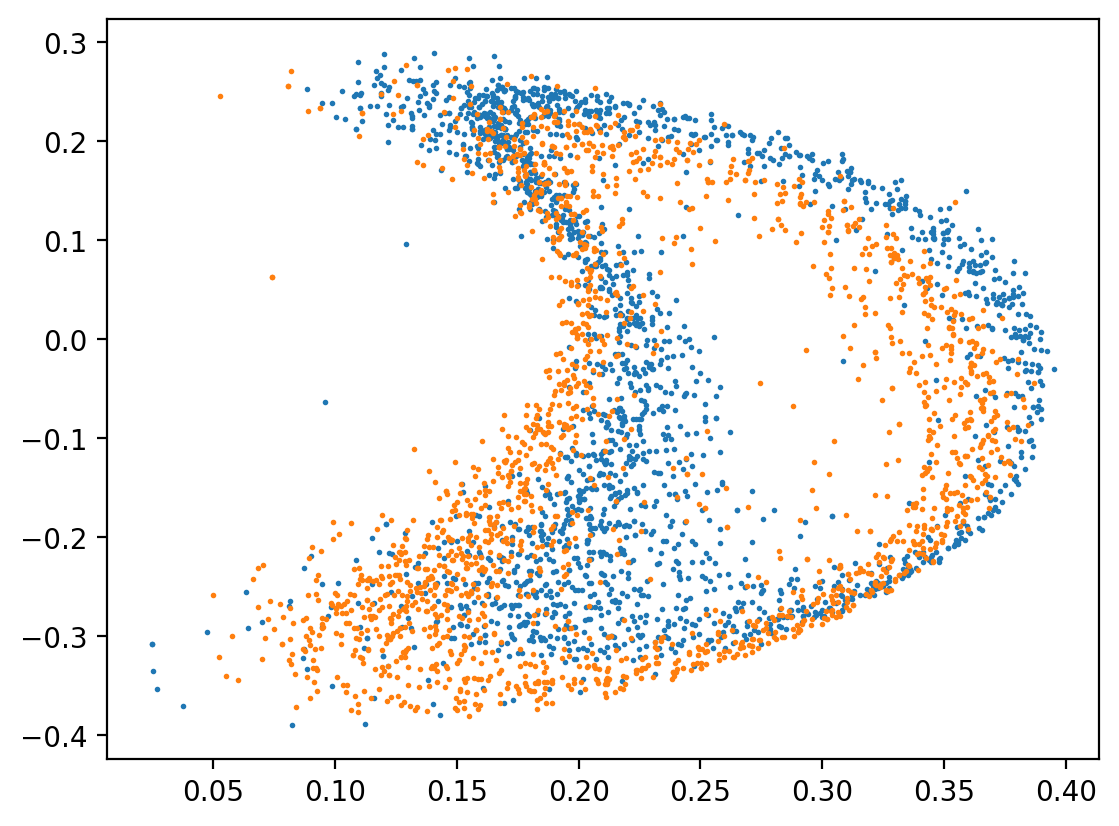

In [377]:
# Check loading
data = np.load("../../data/samples/rhaegal_9m_flightmodes.npz", allow_pickle=True)
initial = data['initial']
flapping = data['flapping']
print(initial.shape)
print(flapping.shape)

# Create pandas dataframe
columns = np.load("../../data/samples/marker_column_names.npy",allow_pickle=True)
initial = pd.DataFrame(initial, columns=columns)
flapping = pd.DataFrame(flapping, columns=columns)

plt.scatter(initial['right_primary_x'], initial['right_primary_z'], s=1)
plt.scatter(initial['left_primary_x'], initial['left_primary_z'], s=1)




## Plotting Flight Modes

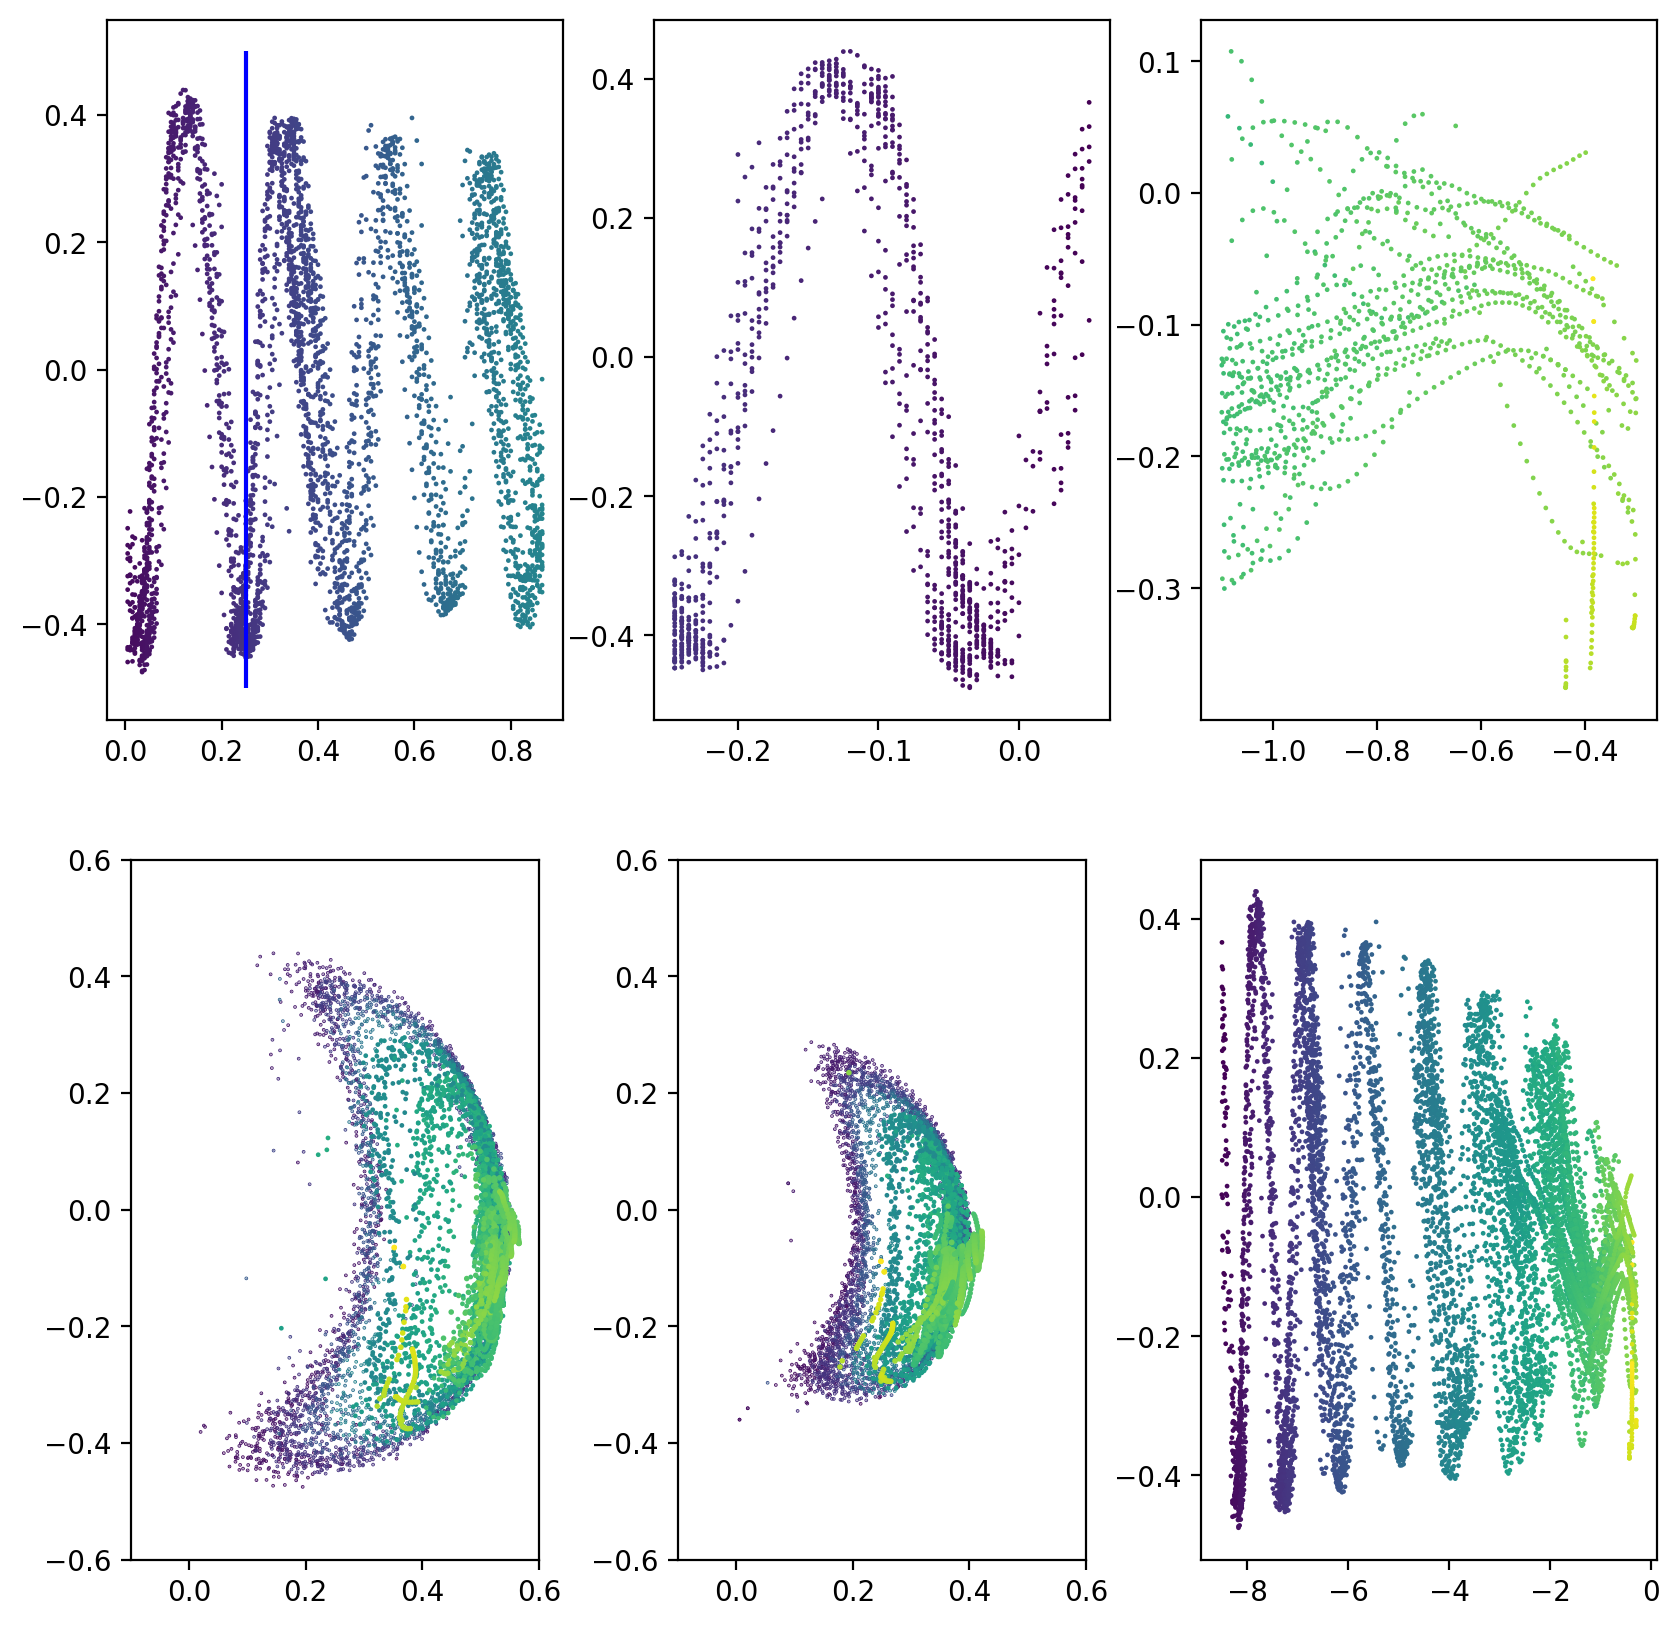

In [350]:

fig, ax = plt.subplots(2, 3, figsize=(10,10))

ax[0,0].scatter(data['time'][flapping], data['left_wingtip_z'][flapping],  s=0.5, c=data['time'][flapping], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[0,0].scatter(data['time'][flapping], data['right_wingtip_z'][flapping], s=0.5, c=data['time'][flapping], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[0,0].vlines(initial_lims[bird][perchDist], -0.5, 0.5, color='b', linestyle='-')

ax[0,1].scatter(-data['time'][initial], data['left_wingtip_z'][initial],  s=0.5, c=data['time'][initial], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[0,1].scatter(-data['time'][initial], data['right_wingtip_z'][initial], s=0.5, c=data['time'][initial], cmap='viridis', clim=(data['time'].min(), data['time'].max()))

ax[0,2].scatter(-data['HorzDistance'][landing], data['left_wingtip_z'][landing],  s=0.5, c=data['time'][landing], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[0,2].scatter(-data['HorzDistance'][landing], data['right_wingtip_z'][landing], s=0.5, c=data['time'][landing], cmap='viridis', clim=(data['time'].min(), data['time'].max()))

ax[1,0].scatter(data['left_wingtip_x'][flapping],  data['left_wingtip_z'][flapping],  s=0.1, c=data['time'][flapping], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,0].scatter(data['right_wingtip_x'][flapping], data['right_wingtip_z'][flapping], s=0.1, c=data['time'][flapping], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,0].scatter(data['left_wingtip_x'][gliding],   data['left_wingtip_z'][gliding],   s=0.5, c=data['time'][gliding],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,0].scatter(data['right_wingtip_x'][gliding],  data['right_wingtip_z'][gliding],  s=0.5, c=data['time'][gliding],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,0].scatter(data['left_wingtip_x'][landing],   data['left_wingtip_z'][landing],   s=1,   c=data['time'][landing],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,0].scatter(data['right_wingtip_x'][landing],  data['right_wingtip_z'][landing],  s=1,   c=data['time'][landing],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))

# Make sure this axis is square
ax[1,0].set_xlim(-0.1, 0.6)
ax[1,0].set_ylim(-0.6, 0.6)
ax[1,0].set_aspect('equal', 'box')


ax[1,1].scatter(data['left_primary_x'][flapping],  data['left_primary_z'][flapping],  s=0.1, c=data['time'][flapping], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,1].scatter(data['right_primary_x'][flapping], data['right_primary_z'][flapping], s=0.1, c=data['time'][flapping], cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,1].scatter(data['left_primary_x'][gliding],   data['left_primary_z'][gliding],   s=0.5, c=data['time'][gliding],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,1].scatter(data['right_primary_x'][gliding],  data['right_primary_z'][gliding],  s=0.5, c=data['time'][gliding],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,1].scatter(data['left_primary_x'][landing],   data['left_primary_z'][landing],   s=1,   c=data['time'][landing],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))
ax[1,1].scatter(data['right_primary_x'][landing],  data['right_primary_z'][landing],  s=1,   c=data['time'][landing],  cmap='viridis', clim=(data['time'].min(), data['time'].max()))

# Make sure this axis is square
ax[1,1].set_xlim(-0.1, 0.6)
ax[1,1].set_ylim(-0.6, 0.6)
ax[1,1].set_aspect('equal', 'box')

ax[1,2].scatter(-data['HorzDistance'], data['left_wingtip_z'], s=0.5, c=data['time'], cmap='viridis')
ax[1,2].scatter(-data['HorzDistance'], data['right_wingtip_z'], s=0.5, c=data['time'], cmap='viridis')

